In [1]:
import gymnasium as gym

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [11]:
class ValueNetwork(nn.Module):

    def __init__(self, n_observations, n_actions, n_hidden):
        super(ValueNetwork, self).__init__()
        self.layer1 = nn.Linear(n_observations + n_actions, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_hidden)
        self.layer3 = nn.Linear(n_hidden, 1)

    # Called with either one element to determine next action, or a batch
    # during optimization.
    def forward(self, states, actions):
        x = torch.cat([states, actions], dim=1)
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

In [12]:
class GaussianPolicy(nn.Module):
    def __init__(self, n_states, n_hidden, n_actions, max_action):
        super(GaussianPolicy, self).__init__()
        self.affine1 = nn.Linear(n_states, n_hidden)
        self.affine2 = nn.Linear(n_hidden, n_hidden)
        self.mean_head = nn.Linear(n_hidden, n_actions)
        self.std_head = nn.Linear(n_hidden, n_actions)
        self.action_scale = 2 * max_action

    def forward(self, x):
        # x is state index; convert to one-hot for the network
        x = F.relu(self.affine1(x))
        x = F.relu(self.affine2(x))
        mean = self.mean_head(x)
        std_dev = self.std_head(x)
        std_dev = torch.clip(std_dev, -self.action_scale/2.0, self.action_scale/2.0)
        return mean, std_dev

    def sample_action(self, state):
        mean, log_std = self.forward(state)
        std = log_std.exp()
        normal = Normal(mean, std)
        x_t = normal.rsample()  # for reparameterization trick (mean + std * N(0,1))
        y_t = torch.tanh(x_t)
        action = y_t * self.action_scale
        log_prob = normal.log_prob(x_t)
        # Enforcing Action Bound
        log_prob -= torch.log(self.action_scale * (1 - y_t.pow(2)) + 1e-6)
        log_prob = log_prob.sum(1, keepdim=True)
        mean = torch.tanh(mean) * self.action_scale
        return action, log_prob, mean

In [13]:
env=gym.make('Pendulum-v1')

n_states = env.observation_space.shape[0]
n_actions = env.action_space.shape[0]

action_range = env.action_space.high - env.action_space.low

possible_actions = np.linspace(0, n_actions-1, n_actions)
LR = 1e-4
GAMMA = 0.9
BATCH_SIZE = 32
EPSILON = 0.01
N_EPISODES = 500
TAU = 0.05
MEM_SIZE = 2000
NOISE_MAX = 0.5

n_hidden = 64

In [14]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [23]:
class SAC():
    def __init__(self):
        # Define the critic A
        self.critic_a = ValueNetwork(n_states, n_actions, n_hidden).to(device)
        self.critic_target_a = ValueNetwork(n_states, n_actions, n_hidden).to(device)
        self.critic_target_a.load_state_dict(self.critic_a.state_dict())

        # Define the critic B
        self.critic_b = ValueNetwork(n_states, n_actions, n_hidden).to(device)
        self.critic_target_b = ValueNetwork(n_states, n_actions, n_hidden).to(device)
        self.critic_target_b.load_state_dict(self.critic_b.state_dict())

        # Define one optimiser for both critics
        self.critic_optimizer = optim.AdamW(list(self.critic_a.parameters()) + list(self.critic_b.parameters()), lr=LR, amsgrad=True)
        
        self.memory = ReplayMemory(MEM_SIZE)

        # Define the actor
        max_action = float(env.action_space.high[0])
        self.actor = GaussianPolicy(n_states, n_hidden, n_actions,max_action)
        self.actor_optimizer = optim.AdamW(self.actor.parameters(), lr=LR, amsgrad=True)

        # Automatic tuning of alpha
        self.target_entropy = -torch.prod(torch.Tensor(env.action_space.shape).to(device)).item()
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_optim = optim.Adam([self.log_alpha], lr=LR)
        self.alpha = 0.0
        
        self.gamma = GAMMA

    def soft_update(self, count):   
        # Soft update of target critic
        for target_param, param in zip(self.critic_target_a.parameters(), self.critic_a.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - TAU) + param.data * TAU)
        for target_param, param in zip(self.critic_target_b.parameters(), self.critic_b.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - TAU) + param.data * TAU)
        
    def learn_actor(self, state_batch):

        # Compute action and std deviation
        actions, log_std, mean = self.actor.sample_action(state_batch)
        
        # Tune alpha automatically
        alpha_loss = -(self.log_alpha * (log_std + self.target_entropy).detach()).mean()
        self.alpha_optim.zero_grad()
        alpha_loss.backward()
        self.alpha_optim.step()
        alpha = self.log_alpha.exp()

        # Compute the loss for the policy
        q_values_a = self.critic_a(state_batch, actions)
        q_values_b = self.critic_b(state_batch, actions)
        
        min_q_values = torch.min(q_values_a, q_values_b)

        actor_loss = ((alpha * log_std) - min_q_values).mean() # Jπ = 𝔼st∼D,εt∼N[α * logπ(f(εt;st)|st) − Q(st,f(εt;st))]

        self.actor_optimizer.zero_grad()        
        actor_loss.backward()
        self.actor_optimizer.step()
    
    def compute_target(self, reward_batch, non_final_mask, non_final_next_states):
        next_q_values = torch.zeros(BATCH_SIZE, device=device)
        
        with torch.no_grad():
            if non_final_mask.any():
                # 1. Sample NEXT action and its log_prob from the policy
                next_actions, next_log_prob, _ = self.actor.sample_action(non_final_next_states)
                
                # 2. Get target Q-values for that specific sampled action
                target_q1 = self.critic_target_a(non_final_next_states, next_actions)
                target_q2 = self.critic_target_b(non_final_next_states, next_actions)
                
                # 3. Apply the SAC target formula: min(Q) - alpha * log_prob
                min_target_q = torch.min(target_q1, target_q2) - self.log_alpha.exp() * next_log_prob
                next_q_values[non_final_mask] = min_target_q.squeeze()
                
        # 4. Final target is reward + (gamma * next_value)
        return reward_batch + (self.gamma * next_q_values)

        
    def learn_critic(self, state_batch, action_batch, reward_batch, non_final_mask, non_final_next_states):     
        # Compute action and log_probability for the NEXT state
        _, log_std_next, _ = self.actor.sample_action(non_final_next_states)
        
        # Q(s, a) from online critic
        q_values_a = self.critic_a(state_batch, action_batch)
        q_values_b = self.critic_b(state_batch, action_batch)
        
        target_value = self.compute_target(reward_batch, non_final_mask, non_final_next_states)
        
        # Compute loss (ensuring both are [Batch, 1])
        criterion = nn.SmoothL1Loss()
        loss = criterion(q_values_a, target_value.unsqueeze(1)) + criterion(q_values_b, target_value.unsqueeze(1))
        
        self.critic_optimizer.zero_grad()
        loss.backward()
        self.critic_optimizer.step()        

In [24]:
def soft_actor_critic(num_episodes=200):
    sac = SAC()
    rewards_list = []
    global_steps = 0

    for e in range(num_episodes):
        obs, info = env.reset()
        # Convert to [1, 3] tensor immediately
        state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        tot_reward = 0
        done = False
        
        while not done:
            # 1. Select Action
            with torch.no_grad():
                action, log_std, mean = sac.actor.sample_action(state)
            
            # 3. Step Environment
            action = action.detach().numpy()[0]
            state_next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            tot_reward += reward

            # 4. Prepare tensors for Memory
            # Keep everything 2D for consistency
            action_tensor = torch.from_numpy(action).float().to(device).unsqueeze(0) # Convert directly from numpy to tensor, then add the batch dimension
            reward_tensor = torch.tensor([reward], dtype=torch.float32, device=device)
            state_next = torch.tensor(state_next_obs, dtype=torch.float32, device=device).unsqueeze(0) if not done else None

            sac.memory.push(state, action_tensor, state_next, reward_tensor)
            state = state_next 

            # 5. Optimize
            if len(sac.memory) >= BATCH_SIZE:
                transitions = sac.memory.sample(BATCH_SIZE)
                batch = Transition(*zip(*transitions))
                
                # Masks and batching
                non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool)
                non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
                
                state_batch = torch.cat(batch.state)   # [32, 3]
                action_batch = torch.cat(batch.action) # [32, 1]
                reward_batch = torch.cat(batch.reward) # [32]

                # Update the policy
                sac.learn_actor(state_batch)

                sac.learn_critic(state_batch, action_batch, reward_batch, non_final_mask, non_final_next_states)
                    
                sac.soft_update(global_steps)
            
            global_steps += 1

        rewards_list.append(tot_reward)
        if e % 10 == 0:
            print(f"Episode {e} | Reward: {tot_reward:.2f}")
            
    return rewards_list

In [25]:
rewards = soft_actor_critic(num_episodes=N_EPISODES)

Episode 0 | Reward: -1127.77
Episode 10 | Reward: -1678.52
Episode 20 | Reward: -1724.09
Episode 30 | Reward: -1485.00
Episode 40 | Reward: -1488.31
Episode 50 | Reward: -1452.96
Episode 60 | Reward: -1497.00
Episode 70 | Reward: -1389.62
Episode 80 | Reward: -1519.83
Episode 90 | Reward: -1131.59
Episode 100 | Reward: -1155.41
Episode 110 | Reward: -1186.97
Episode 120 | Reward: -907.68
Episode 130 | Reward: -913.06
Episode 140 | Reward: -897.94
Episode 150 | Reward: -796.17
Episode 160 | Reward: -924.80
Episode 170 | Reward: -1357.90
Episode 180 | Reward: -948.51
Episode 190 | Reward: -607.41
Episode 200 | Reward: -795.65
Episode 210 | Reward: -793.99
Episode 220 | Reward: -674.25
Episode 230 | Reward: -777.33
Episode 240 | Reward: -651.39
Episode 250 | Reward: -528.20
Episode 260 | Reward: -436.49
Episode 270 | Reward: -413.23
Episode 280 | Reward: -253.55
Episode 290 | Reward: -1001.54
Episode 300 | Reward: -386.25
Episode 310 | Reward: -265.31
Episode 320 | Reward: -253.37
Episode

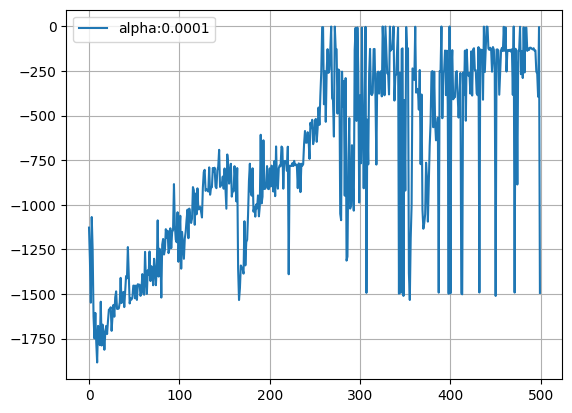

In [26]:
plt.grid()
plt.plot(rewards, label="alpha:"+str(round(LR, 4)))
plt.legend()